# 1D Obstacle Solver

# Numba Version for large N

In [41]:
"""
Gaussian-RBF ADMM (1-D obstacle) — float32 core + float64 tSVD solve
- τ (tSVD threshold) is kept EXACTLY at 1e-15
- No Cholesky path anywhere (tSVD only)
- w-update is solved in float64 with a condition-number cap to prevent overflow
- Early stopping: stop if primal & dual don't improve enough for STALL_PATIENCE iters
- Relative L2 uses trapezoidal rule (np.trapz)
"""

import numpy as np
from numba import njit, prange
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 0) Global dtype & guards
# -----------------------------
DTYPE = np.float32
TINY  = np.float32(1e-30)

# -----------------------------
# 1) User parameters
# -----------------------------
problem  = '2'          # '1' or '2'
N        = 1024
T        =  2.0
zeta     = 2.0
max_iter = 50_000
tau      = 1e-15                 # KEEP EXACTLY
tol      = 1e-8
mu, rho  = ((300.0, 45.0) if problem == '1' else (2.5e4, 250.0))
N = N//8
# Choose kernel shape for RBF
def c_from_T_tau(T, tau):
    return np.pi / (T * np.sqrt(2.0 * np.log(1.0 + tau**(-2))))
c_val  = c_from_T_tau(T, tau)
print(f'c(tau, T) value: {c_val:.3f}')

b  = c_val * N
print(f'Kernel deviation (b_shape): {b:.3f}')

# Optional ADMM stabilization knobs
OVER_RELAX_ALPHA = np.float32(1.0)  # set to 1.5 to try over-relaxation
KAPPA_MAX        = 1e10             # condition number cap for pseudo-inverse (try 1e8..1e12)

# Early stopping knobs
STALL_REL      = np.float32(1e-3)   # require >=0.1% relative improvement
STALL_PATIENCE = 5000               # max consecutive non-improving iterations

# -----------------------------
# 2) Mesh, exact, obstacle
# -----------------------------
M        = np.int32(zeta * N)
x        = np.linspace(0.0, 1.0, M, dtype=DTYPE)
lower_a, upper_b = DTYPE(0.0), DTYPE(1.0)
L = DTYPE(0.5) * (upper_b - lower_a)
q = DTYPE(0.5) * (lower_a + upper_b)



if problem == '1': 
    T_cent = T
elif problem == '2':
    T_cent = np.floor(T)
    
T_cent = DTYPE(T_cent)
centres = np.linspace(q - T_cent * L, q + T_cent * L, N, dtype=DTYPE)
dx       = DTYPE(x[1] - x[0])

def psi1(x):
    x  = np.asarray(x, dtype=DTYPE)
    y  = np.zeros_like(x)
    m1 = x <= DTYPE(0.25)
    m2 = (x > DTYPE(0.25)) & (x <= DTYPE(0.5))
    m3 = x > DTYPE(0.5)
    y[m1] = DTYPE(100.0)*x[m1]**DTYPE(2.0)
    y[m2] = DTYPE(100.0)*x[m2]*(1-x[m2]) - DTYPE(12.5)
    xs    = 1 - x[m3]
    y[m3] = np.where(xs <= DTYPE(0.25),
                     DTYPE(100.0)*xs**DTYPE(2.0),
                     DTYPE(100.0)*xs*(1-xs) - DTYPE(12.5))
    return y

def u1_exact(x):
    x  = np.asarray(x, dtype=DTYPE)
    y  = np.zeros_like(x)
    xc = DTYPE(1.0)/(DTYPE(2.0)*np.sqrt(DTYPE(2.0)))
    m1 = x <= xc
    m2 = (x > xc) & (x <= DTYPE(0.5))
    m3 = x > DTYPE(0.5)
    y[m1] = (DTYPE(100.0)-DTYPE(50.0)*np.sqrt(DTYPE(2.0)))*x[m1]
    y[m2] = DTYPE(100.0)*x[m2]*(1-x[m2]) - DTYPE(12.5)
    xs    = 1 - x[m3]
    y[m3] = np.where(xs <= xc,
                     (DTYPE(100.0)-DTYPE(50.0)*np.sqrt(DTYPE(2.0)))*xs,
                     DTYPE(100.0)*xs*(1-xs) - DTYPE(12.5))
    return y

def psi2(x):
    x  = np.asarray(x, dtype=DTYPE)
    y  = np.zeros_like(x)
    m1 = x <= DTYPE(0.25)
    m2 = (x > DTYPE(0.25)) & (x <= DTYPE(0.5))
    m3 = x > DTYPE(0.5)
    y[m1] = DTYPE(10.0)*np.sin(DTYPE(2.0)*np.pi*x[m1])
    y[m2] = DTYPE(5.0)*np.cos(np.pi*(DTYPE(4.0)*x[m2]-DTYPE(1.0))) + DTYPE(5.0)
    xs    = 1 - x[m3]
    y[m3] = np.where(xs <= DTYPE(0.25),
                     DTYPE(10.0)*np.sin(DTYPE(2.0)*np.pi*xs),
                     DTYPE(5.0)*np.cos(np.pi*(DTYPE(4.0)*xs-DTYPE(1.0))) + DTYPE(5.0))
    return y

def u2_exact(x):
    x  = np.asarray(x, dtype=DTYPE)
    y  = np.zeros_like(x)
    m1 = x <= DTYPE(0.25)
    m2 = (x > DTYPE(0.25)) & (x <= DTYPE(0.5))
    m3 = x > DTYPE(0.5)
    y[m1] = DTYPE(10.0)*np.sin(DTYPE(2.0)*np.pi*x[m1])
    y[m2] = DTYPE(10.0)
    xs    = 1 - x[m3]
    y[m3] = np.where(xs <= DTYPE(0.25),
                     DTYPE(10.0)*np.sin(DTYPE(2.0)*np.pi*xs),
                     DTYPE(10.0))
    return y

psi    = psi1(x) if problem == '1' else psi2(x)
u_true = u1_exact(x) if problem == '1' else u2_exact(x)
u0, u1b = DTYPE(u_true[0]), DTYPE(u_true[-1])

# -----------------------------
# 3) Numba kernels (float32)
# -----------------------------
@njit(fastmath=True, parallel=True)
def phi_matrix(b, N, x, centres):
    m   = x.size
    phi = np.empty((m, N), dtype=DTYPE)
    b2  = DTYPE(b*b)
    inv = DTYPE(1.0)/np.sqrt(DTYPE(N))
    for i in prange(m):
        xi = x[i]
        for j in range(N):
            d = xi - centres[j]
            phi[i, j] = np.exp(-b2*d*d)*inv
    return phi

@njit(fastmath=True, parallel=True)
def dphi_matrix(b, N, x, centres):
    m    = x.size
    dphi = np.empty((m, N), dtype=DTYPE)
    b2   = DTYPE(b*b)
    two  = DTYPE(2.0)*b2
    inv  = DTYPE(1.0)/np.sqrt(DTYPE(N))
    for i in prange(m):
        xi = x[i]
        for j in range(N):
            d    = xi - centres[j]
            expv = np.exp(-b2*d*d)
            dphi[i, j] = (-two*d)*expv*inv
    return dphi

phi  = phi_matrix(b, N, x, centres)
dphi = dphi_matrix(b, N, x, centres)
phiT = phi.T.copy()

# -----------------------------
# 4) System matrices (float32)
# -----------------------------
A1    = (dphi.T @ dphi) * dx
beta  = DTYPE(3e5)
h_bc  = DTYPE(1e-6)
idx0  = np.where(x <= h_bc)[0]
idx1  = np.where(x >= (DTYPE(1.0)-h_bc))[0]
phi0  = phi[idx0]
phi1b = phi[idx1]

u0_vec = np.full(len(idx0), u0, dtype=DTYPE)
u1_vec = np.full(len(idx1), u1b, dtype=DTYPE)
W0     = (dx * np.eye(len(idx0), dtype=DTYPE))
W1     = (dx * np.eye(len(idx1), dtype=DTYPE))

A      = A1 + beta*(phi0.T @ W0 @ phi0 + phi1b.T @ W1 @ phi1b)
lhs    = A + DTYPE(rho)*(phiT @ phi)

# Constant RHS part for w-update (float32 + float64 copy)
rhs_const = beta*(phi0.T @ (W0 @ u0_vec) + phi1b.T @ (W1 @ u1_vec))
rhs_const64 = rhs_const.astype(np.float64, copy=True)

# -----------------------------
# 5) tSVD in float64 (tau fixed), with condition cap
# -----------------------------
U64, S64, VT64 = np.linalg.svd(lhs.astype(np.float64), full_matrices=False)
thresh = float(tau) * float(np.max(S64))           # tau = 1e-15 (unchanged)
keep   = S64 > thresh
if not np.any(keep):
    keep = np.zeros_like(S64, dtype=bool)
    keep[np.argmax(S64)] = True

U64  = U64[:, keep]
S64  = S64[keep]
VT64 = VT64[keep, :]

# Condition-number cap: Seff = max(S, Smax/KAPPA_MAX)
Smax = float(np.max(S64))
Smin_allowed = Smax / float(KAPPA_MAX)
Seff64 = np.maximum(S64, Smin_allowed)
S_inv64 = 1.0 / Seff64   # stable pseudo-inverse scaling (float64)

# -----------------------------
# 6) Trapezoid weights & denominator (np.trapz)
# -----------------------------
trap_w = np.ones_like(x, dtype=DTYPE)
trap_w[0]  = DTYPE(0.5)
trap_w[-1] = DTYPE(0.5)

# Denominator: ∫ u_true^2 dx via np.trapz (float64 outside JIT), cast to float32
norm_u2 = np.trapz((u_true.astype(np.float64))**2, x.astype(np.float64)).astype(DTYPE)
if not np.isfinite(norm_u2) or norm_u2 <= TINY:
    norm_u2 = TINY

# -----------------------------
# 7) ADMM (tSVD-only; w-solve in float64; rest float32) + Early Stopping
# -----------------------------
@njit(fastmath=False, error_model='numpy')
def admm_jit(phi, phiT, psi, u_true,
             mu, rho, dx, max_iter, tol, norm_u2,
             U64, S_inv64, VT64, rhs_const64,
             over_relax_alpha, tiny,
             stall_rel, stall_patience,
             trap_w):
    N = phi.shape[1]
    M = phi.shape[0]

    w = np.zeros(N, dtype=np.float32)
    v = np.zeros(M, dtype=np.float32)
    z = np.zeros(M, dtype=np.float32)
    Pw = np.zeros(M, dtype=np.float32)
    v_prev = np.zeros(M, dtype=np.float32)

    prim_log = np.empty(max_iter, dtype=np.float32)
    dual_log = np.empty(max_iter, dtype=np.float32)
    l2_log   = np.empty(max_iter, dtype=np.float32)

    # safe rho and shrink ratio
    safe_rho = np.float32(rho) if rho != 0 else tiny
    ratio    = (np.float32(mu) * dx) / safe_rho

    # early-stopping trackers
    best_prim = np.float32(1e30)
    best_dual = np.float32(1e30)
    stall_cnt = 0

    for it in range(max_iter):
        # ----- w-update (float64 via tSVD with condition cap) -----
        rhs32 = safe_rho * (phiT @ (v - z))
        rhs64 = rhs32.astype(np.float64) + rhs_const64

        tmp1 = U64.T @ rhs64      # float64
        for k in range(tmp1.size):
            tmp1[k] = tmp1[k] * S_inv64[k]
        w64  = VT64.T @ tmp1      # float64
        w[:] = w64.astype(np.float32)

        # ----- v-update with obstacle + shrink (float32) -----
        Pw[:] = phi @ w
        # over-relaxation (optional): t = alpha*Pw + (1-alpha)*v + z
        t = over_relax_alpha * Pw + (np.float32(1.0) - over_relax_alpha) * v + z
        for i in range(M):
            if t[i] < psi[i]:
                cand = t[i] - ratio
                v[i] = psi[i] if (cand < psi[i]) else cand
            else:
                v[i] = t[i]

        # ----- z-update -----
        z += Pw - v

        # ----- diagnostics (guarded) -----
        r_k = Pw - v
        s_vec = v - v_prev
        v_prev[:] = v

        nu = Pw @ Pw;  nv = v @ v
        if not np.isfinite(nu) or nu < tiny: nu = tiny
        if not np.isfinite(nv) or nv < tiny: nv = tiny
        den_prim = np.sqrt(nu) if np.sqrt(nu) > np.sqrt(nv) else np.sqrt(nv)
        if den_prim < tiny or not np.isfinite(den_prim): den_prim = tiny
        prim = r_k @ r_k / den_prim

        s_k = safe_rho * (phiT @ s_vec)
        dual_denom = np.linalg.norm(safe_rho * (phiT @ z) )
        if not np.isfinite(dual_denom) or dual_denom < tiny: dual_denom = tiny
        dual = np.linalg.norm(s_k ** 2) / dual_denom 

        #  # relative L2 via trapezoid (correctly integral |u-u*|^2)
        diff = Pw - u_true
        diff2 = diff * diff
        l2num = dx * (trap_w @ diff2 ** 2)     # equals np.trapz(diff**2, x)

        if not np.isfinite(l2num) or l2num < 0.0:
            l2num = 0.0
        l2rel = l2num / norm_u2 

        prim_log[it] = prim
        dual_log[it] = dual
        l2_log[it]   = l2rel

        # ----- standard convergence -----
        if prim < np.float32(tol) and dual < np.float32(tol):
            return w, it+1, prim_log[:it+1], dual_log[:it+1], l2_log[:it+1]

        # ----- early stopping (stall) -----
        imp_prim = (best_prim - prim) / (best_prim if best_prim > tiny else tiny)
        imp_dual = (best_dual - dual) / (best_dual if best_dual > tiny else tiny)

        improved = False
        if imp_prim > stall_rel:
            best_prim = prim
            improved = True
        if imp_dual > stall_rel:
            best_dual = dual
            improved = True

        if improved:
            stall_cnt = 0
        else:
            stall_cnt += 1
            if stall_cnt >= stall_patience:
                return w, it+1, prim_log[:it+1], dual_log[:it+1], l2_log[:it+1]

    return w, max_iter, prim_log, dual_log, l2_log

# -----------------------------
# 8) Run solver
# -----------------------------
w_sol, it_conv, prim, dual, l2 = admm_jit(
    phi, phiT, psi, u_true,
    np.float32(mu), np.float32(rho), dx, max_iter, np.float32(tol), norm_u2,
    U64, S_inv64, VT64, rhs_const64,
    np.float32(OVER_RELAX_ALPHA), TINY,
    STALL_REL, STALL_PATIENCE,
    trap_w
)

u_final = phi @ w_sol
diff = (u_final - u_true)
# pointwise absolute error to plot
abs_err = np.abs(diff ** 2)


# -----------------------------
# 9) Progress print
# -----------------------------
check_pts = list(range(0, it_conv, 1000)) + [max(it_conv-1, 0)]
print("\nit    prim      dual      rel-L2")
for k in sorted(set(check_pts)):
    print(f"{k:5d}  {float(prim[k]):.3e}  {float(dual[k]):.3e}  {float(l2[k]):.3e}")


print(f"\n=== converged in {it_conv} iterations ===")
print(f"final relative L2 error: {float(l2[-1]):.3e}")


c(tau, T) value: 0.134
Kernel deviation (b_shape): 17.106

it    prim      dual      rel-L2
    0  1.056e+02  4.778e+03  9.167e+01
 1000  3.553e-06  5.416e-01  6.499e-01
 2000  9.229e-06  2.063e-01  4.000e-02
 3000  4.165e-07  5.890e-02  2.871e-03
 4000  2.733e-06  4.117e-02  2.240e-04
 5000  1.054e-06  2.126e-01  1.979e-05
 6000  3.892e-07  1.430e-02  2.007e-06
 7000  5.168e-07  5.322e-02  2.351e-07
 8000  5.016e-06  1.769e-02  3.805e-08
 9000  4.218e-06  4.294e-03  1.187e-08
10000  2.025e-06  2.669e-03  6.415e-09
11000  9.060e-07  2.377e-02  5.068e-09
12000  1.065e-06  4.149e-03  4.673e-09
13000  9.493e-07  2.046e-02  4.726e-09
14000  7.761e-07  3.726e-02  3.805e-09
15000  3.584e-07  2.417e-02  4.428e-09
16000  3.281e-06  2.581e-02  4.442e-09
17000  1.835e-06  4.277e-03  4.165e-09
18000  1.680e-06  9.402e-02  4.822e-09
19000  4.967e-06  2.176e-02  3.625e-09
20000  2.499e-06  1.186e-01  3.757e-09
21000  8.020e-07  1.754e-01  4.985e-09
22000  1.793e-06  2.348e-03  5.123e-09
22973  6.33

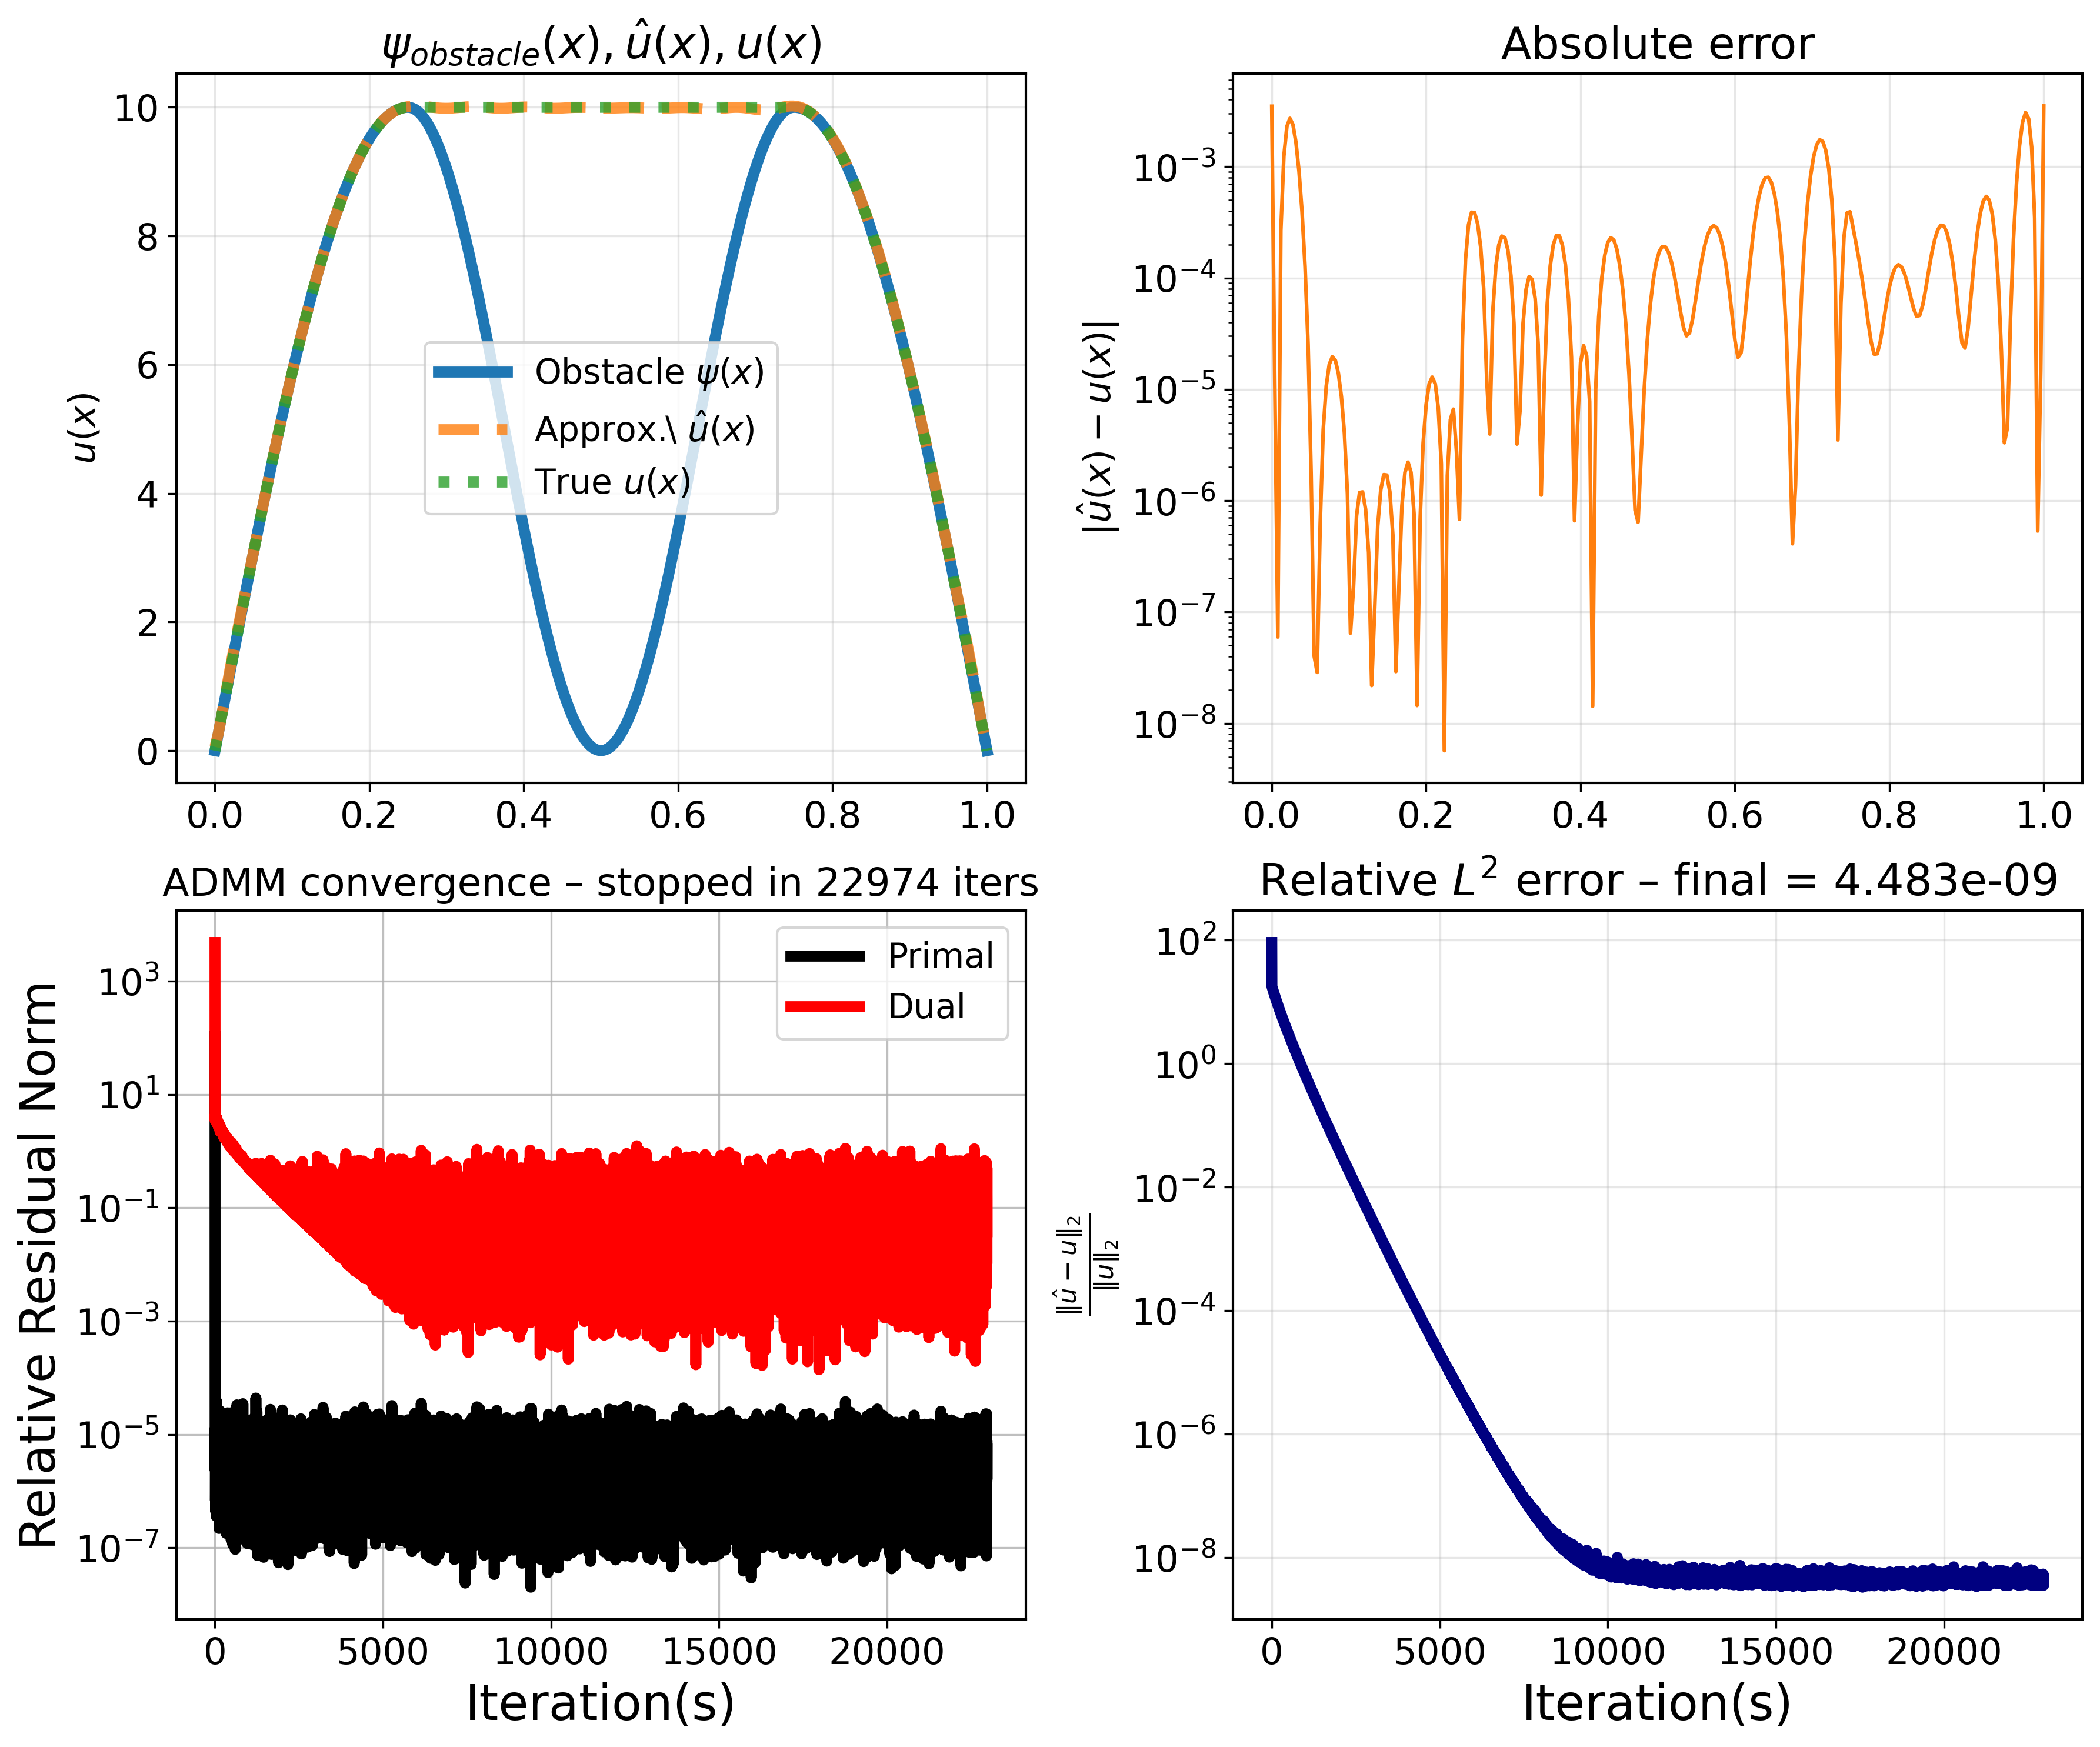

In [42]:


plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.labelsize': 20,
    'axes.titlesize': 20,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'lines.linewidth': 4.0,
    'grid.linestyle': '-',
    'grid.alpha': 0.7,
    'figure.dpi': 300,
})


# ── 1. convenience ----------------------------------------------------
iterations = np.arange(len(prim))


# ── 2. Figure & style (publication-ready) -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
lw = 4.5                  # desired line width

# ── (1, 1) obstacle / approx / true -----------------------------------
ax = axes[0, 0]
ax.plot(x, psi,     lw=lw, label=r'Obstacle $\psi(x)$', linestyle='-',  color='tab:blue')
ax.plot(x, u_final, lw=lw, label=r'Approx.\ $\hat{u}(x)$', linestyle='--', color='tab:orange', alpha=0.8)
ax.plot(x, u_true,  lw=lw, label=r'True $u(x)$',       linestyle=':',  color='tab:green',  alpha=0.8)

ax.set_title(r'$\psi_{obstacle}(x), \hat{u}(x), u(x)$', fontsize=18)
ax.set_ylabel(r'$u(x)$', fontsize = 15);  ax.grid(alpha=0.3)
ax.legend(fontsize=14)

# ── (1, 2) absolute error ---------------------------------------------
ax = axes[0, 1]
ax.semilogy(x, abs_err, lw=1.5, label=r'$\hat{u}(x) - u(x)$', color = 'tab:orange', linestyle = '-')
ax.set_title('Absolute error', fontsize=18)
ax.set_ylabel(r'$ | \hat{u}(x) - u(x) |$', fontsize = 15)
ax.grid(alpha=0.3)

# ── (2, 1) ADMM residuals ---------------------------------------------
ax = axes[1, 0]
ax.semilogy(iterations, prim, lw=lw, label='Primal', color = 'black')
ax.semilogy(iterations, dual, lw=lw, label='Dual', color = 'red')
ax.set_title(f'ADMM convergence – stopped in {it_conv} iters', fontsize=16)
ax.set_xlabel('Iteration(s)');  ax.set_ylabel('Relative Residual Norm');  ax.grid(alpha=0.8)
ax.legend(fontsize=14)

# ── (2, 2) relative L2 error ------------------------------------------
ax = axes[1, 1]
ax.semilogy(iterations, l2, lw=lw, color = 'navy')
ax.set_title(f'Relative $L^2$ error – final = {l2[-1]:.3e}', fontsize=18)
ax.set_xlabel('Iteration(s)');
ax.set_ylabel(r'$\frac{ \| \hat{u} - u \|_{2}}{\| u \|_{2} }$', fontsize = 15)
ax.grid(alpha=0.3)

# ── 3. global tweaks ---------------------------------------------------
for ax in axes.flat:
    ax.tick_params(labelsize=15)
fig.tight_layout()



if problem == '1':
    plt.savefig('./Outputs/1D_Obstacle/Problem1/fig_obstacle1D_single_bump.png')
    #files.download('fig_obstacle1D_single_bump.png')
elif problem == '2':
    plt.savefig('./Outputs/1D_Obstacle/Problem2/fig_obstacle1D_two_bump.png')
    #files.download('fig_obstacle1D_two_bump.png')

# Benchmark Performance Metrics

In [3]:
from __future__ import annotations
import time
import tracemalloc
import numpy as np
from numpy.linalg import svd
from numba import njit

# ------------------------------------------------------------------
# 1. obstacle & exact-solution factories
# ------------------------------------------------------------------
def _psi_u_factory(problem: str):
    """Return obstacle psi(x) and exact u(x) callables for the chosen case."""
    if problem == "1":                                           # single bump
        def psi(x):
            x = np.asarray(x); y = np.zeros_like(x)
            m1, m2 = x <= .25, (x > .25) & (x <= .5); m3 = x > .5
            y[m1] = 100*x[m1]**2
            y[m2] = 100*x[m2]*(1-x[m2]) - 12.5
            xs = 1-x[m3]
            y[m3] = np.where(xs <= .25, 100*xs**2,
                              100*xs*(1-xs) - 12.5)
            return y

        def u_exact(x):
            x = np.asarray(x); y = np.zeros_like(x)
            xc = 1/(2*np.sqrt(2))
            m1 = (x <= xc)
            m2 = (x > xc) & (x <= .5)
            m3 = (x > 0.5)
            y[m1] = (100-50*np.sqrt(2))*x[m1]
            y[m2] = 100*x[m2]*(1-x[m2]) - 12.5
            xs = 1-x[m3]
            y[m3] = np.where(xs <= xc, (100-50*np.sqrt(2))*xs,
                              100*xs*(1-xs) - 12.5)
            return y
        return psi, u_exact, dict(mu=300.0, rho=45.0)            # penalty pair

    if problem == "2":                                           # two bumps
        def psi(x):
            x = np.asarray(x); y = np.zeros_like(x)
            m1, m2 = x <= .25, (x > .25) & (x <= .5); m3 = x > .5
            y[m1] = 10*np.sin(2*np.pi*x[m1])
            y[m2] = 5*np.cos(np.pi*(4*x[m2]-1)) + 5
            xs = 1-x[m3]
            y[m3] = np.where(xs <= .25, 10*np.sin(2*np.pi*xs),
                              5*np.cos(np.pi*(4*xs-1)) + 5)
            return y

        def u_exact(x):
            x = np.asarray(x); y = np.zeros_like(x)
            m1, m2 = x <= .25, (x > .25) & (x <= .5); m3 = x > .5
            y[m1] = 10*np.sin(2*np.pi*x[m1])
            y[m2] = 10.0
            xs = 1-x[m3]
            y[m3] = np.where(xs <= .25, 10*np.sin(2*np.pi*xs), 10.0)
            return y
        return psi, u_exact, dict(mu=2.5e4, rho=250.0)

    raise ValueError("problem must be '1' or '2'")


# ------------------------------------------------------------------
# 2. Gaussian RBF basis & its derivative (Numba-JIT)
# ------------------------------------------------------------------
@njit(fastmath=True)
def _phi_mat(b, N, x, c):
    m = x.size; phi = np.empty((m, N)); b2 = b*b; inv = 1/np.sqrt(N)
    for i in range(m):
        for j in range(N):
            d = x[i] - c[j]
            phi[i, j] = np.exp(-b2*d*d)*inv
    return phi

@njit(fastmath=True)
def _dphi_mat(b, N, x, c):
    m = x.size; dphi = np.empty((m, N)); b2 = b*b; two = 2*b2; inv = 1/np.sqrt(N)
    for i in range(m):
        for j in range(N):
            d = x[i] - c[j]
            dphi[i, j] = -two*d*np.exp(-b2*d*d)*inv
    return dphi


# ------------------------------------------------------------------
# 3. ADMM core (Numba-JIT, same as before but modular)
# ------------------------------------------------------------------
# --- JIT kernel with BC-rhs passed in ---------------------------------
@njit(fastmath=True)
def _admm(phi, psi, bc_rhs,          # <-- NEW: pre-assembled BC term
          U, S_inv, VT, mu, rho, beta, dx,
          u_true, max_iter, tol):

    def svd_solve(rhs):
        tmp = U.T @ rhs
        tmp *= S_inv
        return VT.T @ tmp

    N_, M = phi.shape[1], phi.shape[0]
    w = np.zeros(N_); v = phi @ w; z = np.zeros(M)
    v_prev = v.copy()

    norm_u2 = np.dot(u_true, u_true)

    for it in range(max_iter):
        # w-update
        rhs = rho * phi.T @ (v - z) + bc_rhs      # ← much simpler now
        w   = svd_solve(rhs)

        # v-update (projection + ℓ¹ prox)
        Pw = phi @ w
        ratio = mu*dx / rho
        for i in range(M):
            t = Pw[i] + z[i]
            if t < psi[i]:
                v[i] = psi[i] if t - ratio < psi[i] else t - ratio
            else:
                v[i] = t

        # z-update
        z += Pw - v

        # stopping checks
        r_k = Pw - v
        s_k = rho * (phi.T @ (v - v_prev))
        v_prev[:] = v
        prim = np.linalg.norm(r_k) / max(np.linalg.norm(Pw),
                                         np.linalg.norm(v), 1e-30)
        dual = np.linalg.norm(s_k) / max(np.linalg.norm(rho*phi.T@z), 1e-30)
        if prim < tol and dual < tol:
            rel_err = np.dot(Pw - u_true, Pw - u_true) / norm_u2
            return Pw, rel_err, it+1

    rel_err = np.dot(Pw - u_true, Pw - u_true) / norm_u2
    return Pw, rel_err, max_iter



# ------------------------------------------------------------------
# 4. Public driver
# ------------------------------------------------------------------
def obstacle_1d(*,
                problem: str = "1",
                N: int = 100,
                T: int = 2,
                c: float = 0.95,
                max_iter: int = 50_000,
                beta: float = 3e5,
                tau: float = 1e-15,
                tol: float = 1e-10):
    """
    Solve 1-D obstacle problem and return:
        (N, M, relative_error, computational_time_sec, memory_peak_MB)
    """
    # grids & basis
    M = T * N
    x = np.linspace(0.0, 1.0, M)
    centres = np.linspace(0.0, 1.0, N)
    dx = x[1] - x[0]
    b = c * N

    # obstacle + exact
    psi_fun, u_fun, penalties = _psi_u_factory(problem)
    psi = psi_fun(x)
    u_true = u_fun(x)
    mu, rho = penalties["mu"], penalties["rho"]

    # basis matrices
    phi  = _phi_mat(b, N, x, centres)
    dphi = _dphi_mat(b, N, x, centres)

    # weak BC data
    u0, u1b = u_true[0], u_true[-1]
    h_bc = 1e-6
    idx0 = np.where(x <= h_bc)[0]
    idx1 = np.where(x >= 1-h_bc)[0]
    phi0, phi1b = phi[idx0], phi[idx1]
    u0_vec, u1_vec = np.full(len(idx0), u0), np.full(len(idx1), u1b)
    W0 = dx*np.eye(len(idx0)); W1 = dx*np.eye(len(idx1))

    # system matrices
    # ----- inside obstacle_1d, just before the SVD ------------------------
    # ---------------------------------------------------------
    # assemble system (inside obstacle_1d)
    # ---------------------------------------------------------
    A1   = dphi.T @ dphi * dx             # stiffness
    Abc  = beta * (                       #  <-- restore BC matrix
        phi0.T @ W0 @ phi0 +
        phi1b.T @ W1 @ phi1b )

    bc_rhs = beta * (                     # BC vector (already OK)
        phi0.T @ (W0 @ u0_vec) +
        phi1b.T @ (W1 @ u1_vec) )

    lhs  = A1 + Abc + rho * (phi.T @ phi) #  <-- add Abc back in

    # SVD pre-factorisation
    U, S, VT = svd(lhs, full_matrices=False)
    S_inv = np.where(S > tau*S.max(), 1.0/S, 0.0)

    # -------------------------------------------------- timing + memory
    tracemalloc.start()
    t0 = time.perf_counter()

    u_num, rel_err, iters = _admm(
    phi, psi, bc_rhs,                # <-- NEW parameter
    U, S_inv, VT, mu, rho, beta, dx,
    u_true, max_iter, tol)

    comp_time = time.perf_counter() - t0
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    mem_peak_MB = peak / 1024**2

    return N, M, rel_err, comp_time, mem_peak_MB

In [4]:
    metrics = obstacle_1d(problem="1", N=100)
    print(f"N={metrics[0]},  M={metrics[1]},  rel_err={metrics[2]:.3e},  "
          f"time={metrics[3]:.2f}s,  mem={metrics[4]:.1f} MB")

N=100,  M=200,  rel_err=1.610e-07,  time=6.50s,  mem=8.2 MB


## Benchmark performance

In [43]:
N_values = [20, 40, 60, 80, 100, 120, 140, 160, 180]
c_vals = [95/n for n in N_values]
problem = "2"

In [44]:
import pandas as pd
records = []
for N, c in zip(N_values, c_vals):
  N_out, m, rel_error, comp_time, mem_peak_MB = obstacle_1d(problem=problem, N=N, c=c)
  print(f"N={N_out}, Gridsize m={m},  rel_err={rel_error:.3e},  "
        f"time={comp_time:.3f}s,  mem={mem_peak_MB:.3e} MB")
  records.append((dict(N = N_out,
                       m = m,
                       rel_error = rel_error,
                       comp_time = comp_time,
                       mem_peak_MB = mem_peak_MB)))

N=20, Gridsize m=40,  rel_err=1.129e+03,  time=4.118s,  mem=1.145e-02 MB
N=40, Gridsize m=80,  rel_err=4.226e-01,  time=0.043s,  mem=2.812e-02 MB
N=60, Gridsize m=120,  rel_err=2.068e-01,  time=0.235s,  mem=6.001e-02 MB
N=80, Gridsize m=160,  rel_err=2.838e-04,  time=3.960s,  mem=1.041e-01 MB
N=100, Gridsize m=200,  rel_err=5.856e-07,  time=8.652s,  mem=1.604e-01 MB
N=120, Gridsize m=240,  rel_err=3.363e-07,  time=14.689s,  mem=2.289e-01 MB
N=140, Gridsize m=280,  rel_err=3.180e-07,  time=19.842s,  mem=3.096e-01 MB
N=160, Gridsize m=320,  rel_err=4.104e-07,  time=24.113s,  mem=4.026e-01 MB
N=180, Gridsize m=360,  rel_err=5.880e-07,  time=31.472s,  mem=5.077e-01 MB


In [45]:
print(records)

[{'N': 20, 'm': 40, 'rel_error': 1128.996580160621, 'comp_time': 4.118196175999401, 'mem_peak_MB': 0.011453628540039062}, {'N': 40, 'm': 80, 'rel_error': 0.42263008810130515, 'comp_time': 0.04316783000012947, 'mem_peak_MB': 0.0281219482421875}, {'N': 60, 'm': 120, 'rel_error': 0.20682455890434942, 'comp_time': 0.23463205400003062, 'mem_peak_MB': 0.0600128173828125}, {'N': 80, 'm': 160, 'rel_error': 0.0002838380359980245, 'comp_time': 3.95979454099961, 'mem_peak_MB': 0.1041107177734375}, {'N': 100, 'm': 200, 'rel_error': 5.855684711458081e-07, 'comp_time': 8.652198994999708, 'mem_peak_MB': 0.1604156494140625}, {'N': 120, 'm': 240, 'rel_error': 3.362970302351354e-07, 'comp_time': 14.688623652999922, 'mem_peak_MB': 0.2289276123046875}, {'N': 140, 'm': 280, 'rel_error': 3.1797385101207475e-07, 'comp_time': 19.84228085900031, 'mem_peak_MB': 0.3096466064453125}, {'N': 160, 'm': 320, 'rel_error': 4.104241304791603e-07, 'comp_time': 24.11341705199993, 'mem_peak_MB': 0.4025726318359375}, {'N': 


---- collected data ----
  N   m rel_error comp_time mem_peak_MB
 20  40 1.129e+03     4.118   1.145e-02
 40  80 4.226e-01     0.043   2.812e-02
 60 120 2.068e-01     0.235   6.001e-02
 80 160 2.838e-04     3.960   1.041e-01
100 200 5.856e-07     8.652   1.604e-01
120 240 3.363e-07    14.689   2.289e-01
140 280 3.180e-07    19.842   3.096e-01
160 320 4.104e-07    24.113   4.026e-01
180 360 5.880e-07    31.472   5.077e-01


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Fitted models:
  memory ~ 1.555e-03·M + -0.11
  time   ~ N^2.035
  error  ~ N^-10.961


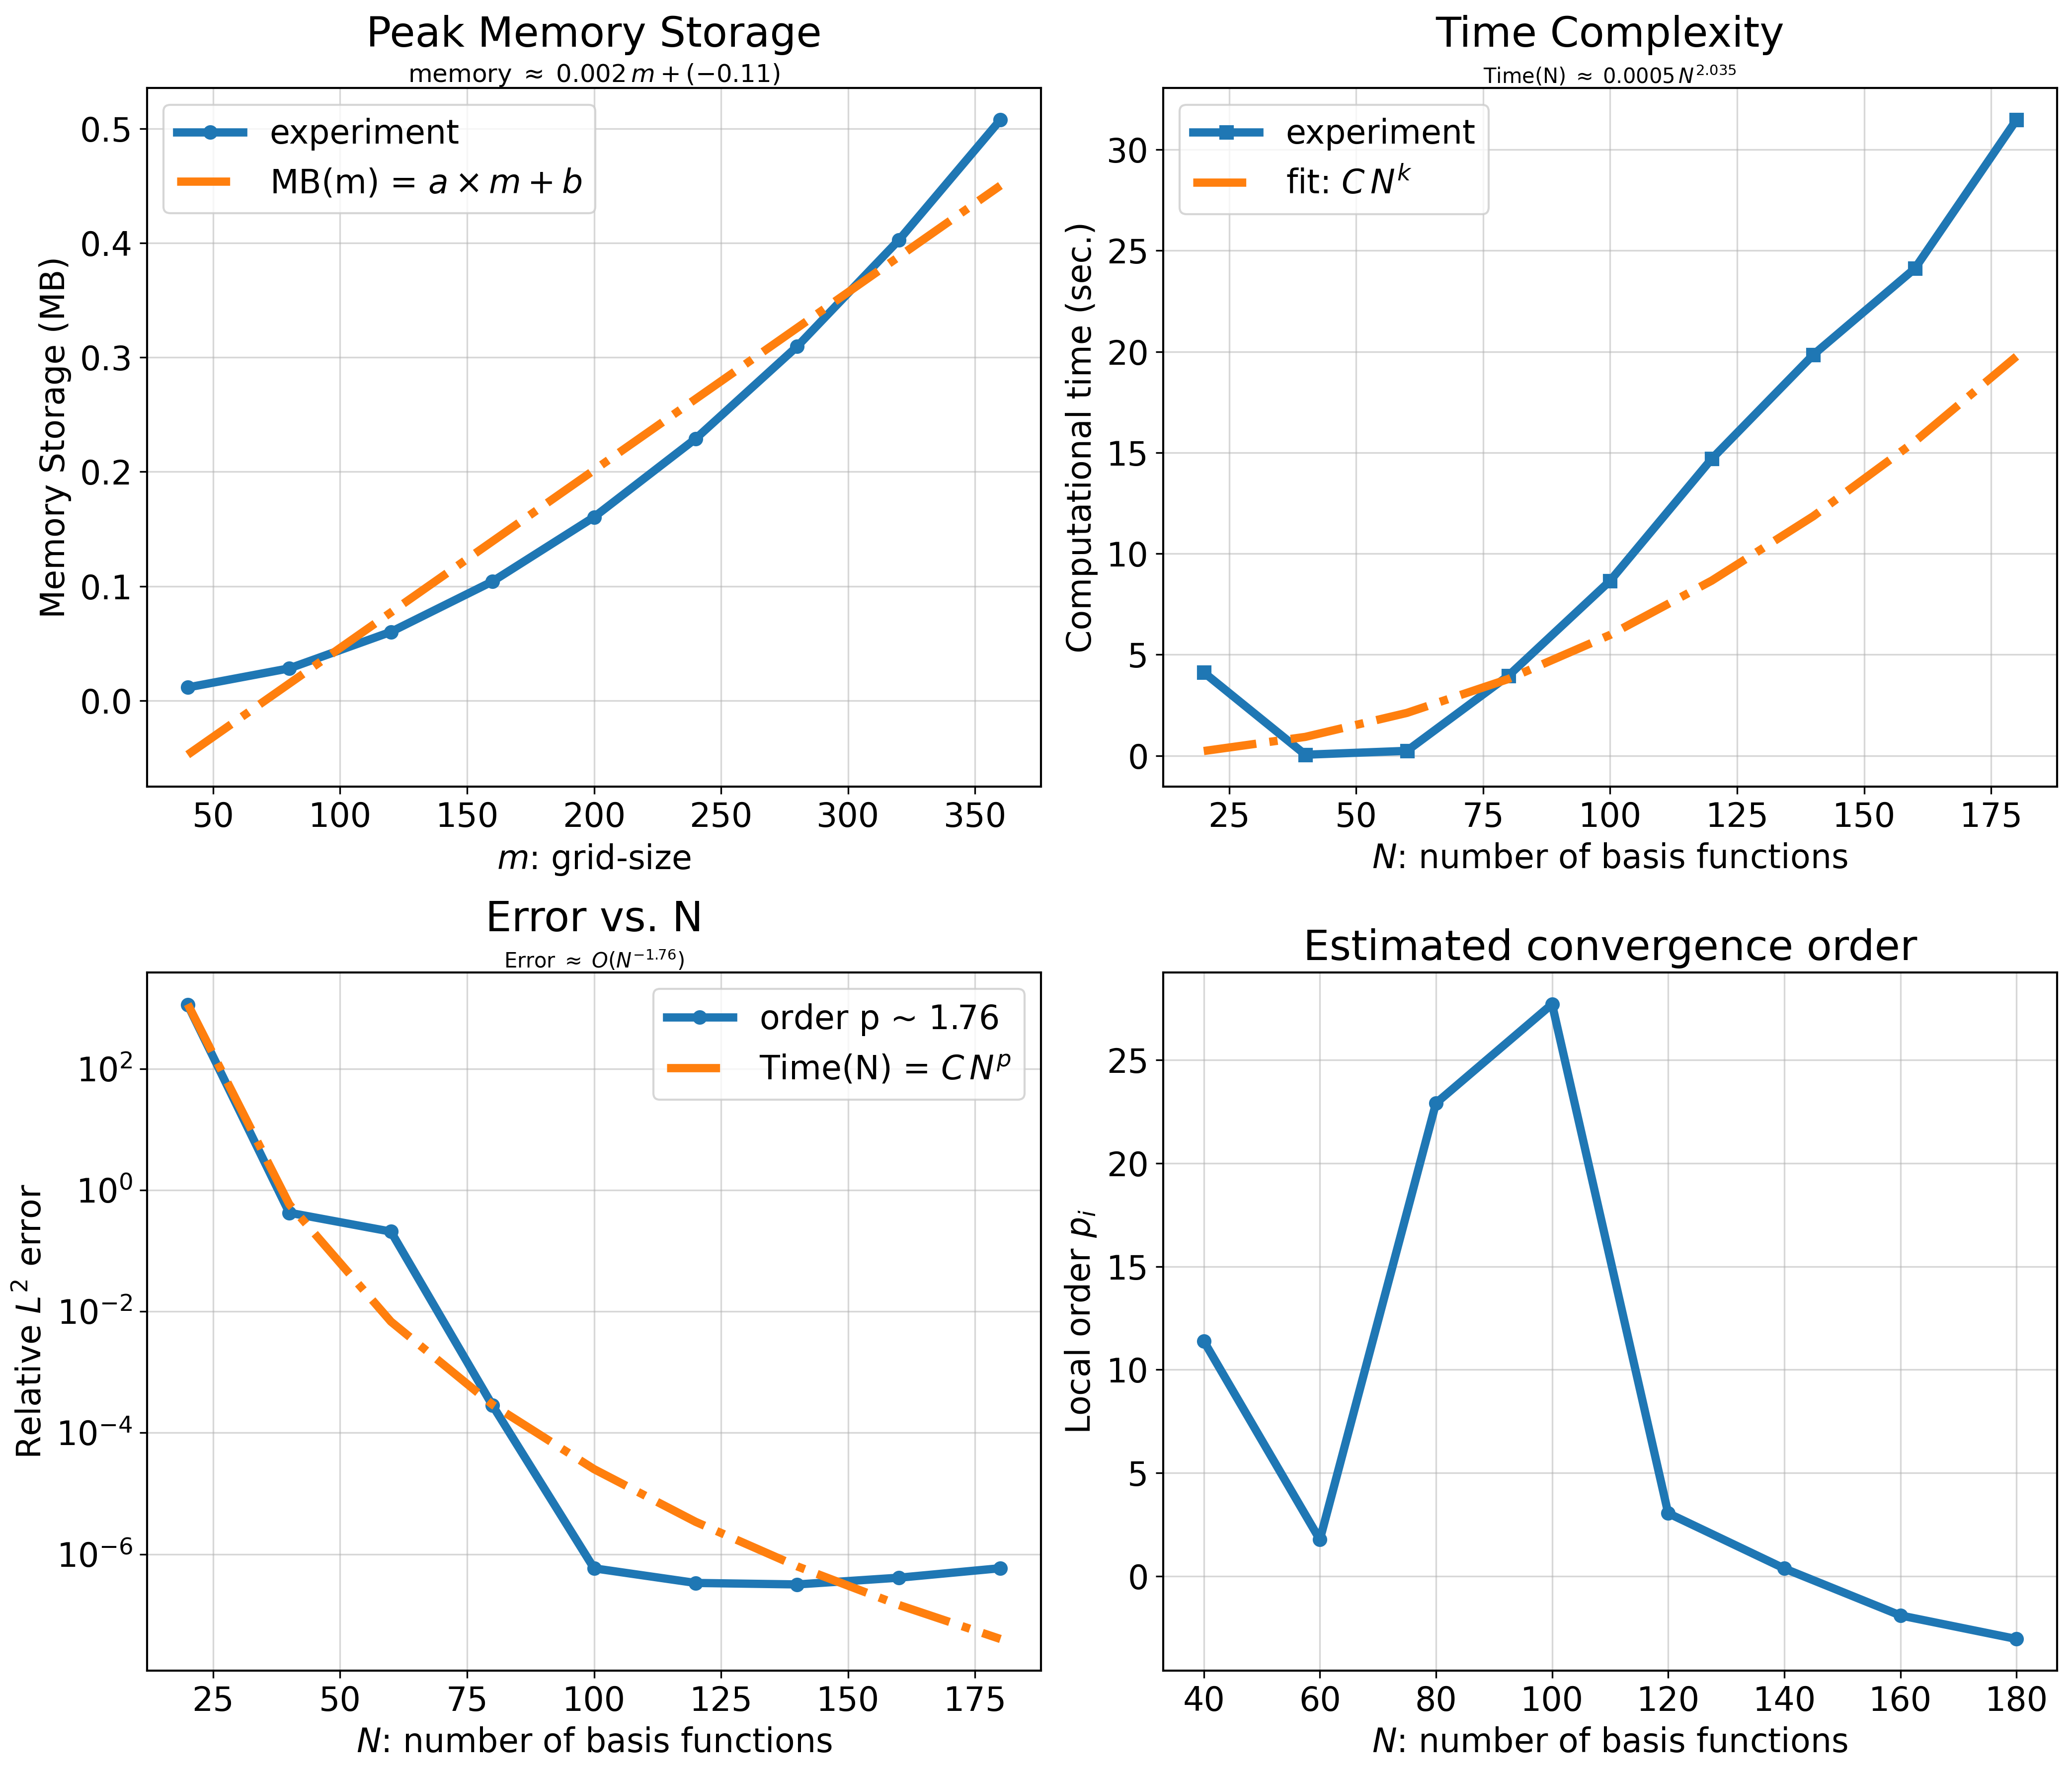

In [46]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.labelsize': 16,
    'axes.titlesize': 20,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'lines.linewidth': 4.0,
    'grid.linestyle': '-',
    'grid.alpha': 0.5,
    'figure.dpi': 300,
})


df = pd.DataFrame(records)
print("\n---- collected data ----")
print(df.to_string(index=False, formatters={
    "rel_error": "{:.3e}".format,
    "comp_time": "{:.3f}".format,
    "mem_peak_MB": "{:.3e}".format
}))



# ----------------------------------------------------------
# 3) prepare variables for fits / plots
# ----------------------------------------------------------
N_vals   = df["N"].to_numpy()
M_vals   = df["m"].to_numpy()
err_vals = df["rel_error"].to_numpy()
time_vals= df["comp_time"].to_numpy()
mem_vals = df["mem_peak_MB"].to_numpy()

# fits
a_mem, b_mem = np.polyfit(M_vals, mem_vals, 1)
mem_fit = a_mem * M_vals + b_mem

k_time, logC_time = np.polyfit(np.log(N_vals), np.log(time_vals), 1)
time_fit = np.exp(logC_time) * N_vals**k_time
Ctime = np.exp(logC_time)
p_err, logC_err = np.polyfit(np.log(N_vals), np.log(err_vals), 1)
err_fit = np.exp(logC_err) * N_vals**p_err
Cerror = np.exp(logC_err)
p_i  = -np.diff(np.log(err_vals)) / np.diff(np.log(N_vals))
N_mid = N_vals[1:]

# ----------------------------------------------------------
# 4) plotting (2 × 2 grid)
# ----------------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# (top-left) memory vs M
axs[0, 0].plot(M_vals, mem_vals, "o-", label="experiment")
axs[0, 0].plot(M_vals, mem_fit, "-.", label=f"MB(m) = $a \\times m + b$")
axs[0, 0].set_xlabel("$m$: grid-size")
axs[0, 0].set_ylabel("Memory Storage (MB)")
axs[0, 0].set_title("Peak Memory Storage", pad = 20)
axs[0, 0].text(0.5, 1.0,
               rf"$\text{{memory}}\;\approx\;{a_mem:.3f}\,m + ({b_mem:.2f})$",
               ha="center", va="bottom", transform=axs[0, 0].transAxes,
               fontsize=12)
axs[0, 0].legend()
axs[0, 0].grid(True)

# (top-right) time vs N
axs[0, 1].plot(N_vals, time_vals, "s-", label="experiment")
axs[0, 1].plot(N_vals, time_fit, "-.", label=f"fit: $C\,N^k$")
axs[0, 1].set_xlabel("$N$: number of basis functions")
axs[0, 1].set_ylabel("Computational time (sec.)")
axs[0, 1].set_title("Time Complexity", pad = 20)
axs[0, 1].text(0.5, 1.00,
               rf"$\text{{Time(N)}}\;\approx\; {Ctime:.4f} \, N^{{{k_time:.3f}}}$",
               ha="center", va="bottom", transform=axs[0, 1].transAxes,
               fontsize=10)
axs[0, 1].legend()
axs[0, 1].grid(True)

# (bottom-left) error vs N (log scale)
axs[1, 0].plot(N_vals, err_vals, "o-", label=f"order p ~ $1.76$")
axs[1, 0].plot(N_vals, err_fit, "-.", label=f"Time(N) = $C\,N^p$")
axs[1, 0].set_yscale("log")
axs[1, 0].set_xlabel("$N$: number of basis functions")
axs[1, 0].set_ylabel("Relative $L^2$ error")
axs[1, 0].set_title("Error vs. N", pad = 20)
axs[1, 0].text(0.5, 1.00,
               rf"$\text{{Error}}\;\approx\; O(N^{{-1.76}})$",
               ha="center", va="bottom", transform=axs[1, 0].transAxes,
               fontsize=10)
axs[1, 0].legend()
axs[1, 0].grid(True)

# (bottom-right) local convergence order p_i
axs[1, 1].plot(N_mid, p_i, "-o")
axs[1, 1].set_xlabel("$N$: number of basis functions")
axs[1, 1].set_ylabel(r"Local order $p_i$")
axs[1, 1].set_title("Estimated convergence order")
axs[1, 1].grid(True)

fig.tight_layout()
if problem == "1":
  plt.savefig('fig2_obstacle_1d_benchmark_one_bump.png')
  files.download('fig2_obstacle_1d_benchmark_one_bump.png')
elif problem == "2":
  plt.savefig('fig2_obstacle_1d_benchmark_two_bumps.png')
  files.download('fig2_obstacle_1d_benchmark_two_bumps.png')
#plt.show()

# ----------------------------------------------------------
# 5) print fitted exponents
# ----------------------------------------------------------
print("\nFitted models:")
print(f"  memory ~ {a_mem:.3e}·M + {b_mem:.2f}")
print(f"  time   ~ N^{k_time:.3f}")
print(f"  error  ~ N^{p_err:.3f}")